In [1]:
import sys, json
from pathlib import Path
repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

In [3]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
plt.rcParams.update({
    'font.family':        'serif',
    'font.size':          11,
    'axes.titlesize':     12,
    'axes.labelsize':     11,
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
    'legend.fontsize':    9,
    'figure.facecolor':   'white',
    'axes.facecolor':     'white',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.25,
    'grid.linestyle':     '--',
    'lines.linewidth':    2.0,
    'lines.markersize':   5,
    'savefig.dpi':        150,
    'savefig.bbox':       'tight',
})

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent

# ---- Configure dataset here ----
DATASET = "celeba"  # or "celebahq"
base = repo_root / "output" / "smile_classification" / DATASET
certify_dir = base / "certify"

# Mode tags match CertifyPaths.from_config:
#   {pixel|latent}_{manifold|isotropic}
MODES = ["pixel_isotropic", "pixel_manifold", "latent_isotropic", "latent_manifold"]
SIGMAS = [
    "sigma_0_02",
          "sigma_0_05",
          "sigma_0_07",
           "sigma_0_10",
          "sigma_0_15",
          "sigma_0_20",
          "sigma_0_25", 
          "sigma_0_30",
          "sigma_0_35",
          "sigma_0_40",
          "sigma_0_45", 
          "sigma_0_50",
          "sigma_0_55",
          "sigma_0_60",
          "sigma_0_65", 
          "sigma_0_70",  
          "sigma_0_75", 
          "sigma_0_80",
          "sigma_0_85", 
          "sigma_0_90",  
          "sigma_0_95", 
          "sigma_1_00"]

def sigma_val(s):
    return float(s.replace("sigma_", "").replace("_", "."))

def load_metrics(folder):
    """Load metrics.json from a certify experiment folder."""
    if not folder.exists():
        return None
    p = folder / "metrics.json"
    if p.exists():
        with open(p) as f:
            return json.load(f)
    return None

def load_results_csv(folder):
    """Load per-sample results.csv."""
    p = folder / "results.csv"
    if p.exists():
        return pd.read_csv(p)
    return None

def mode_label(mode):
    """Pretty label: 'pixel_manifold' -> 'Pixel Manifold'."""
    return mode.replace('_', ' ').title()

# Discover what results exist
found = []
for mode in MODES:
    for sig in SIGMAS:
        p = certify_dir / mode / sig
        m = load_metrics(p)
        if m:
            found.append((mode, sig, sigma_val(sig)))

print(f"Dataset: {DATASET}")
print(f"Base: {base}")
print(f"Found {len(found)} experiment results:")
for mode, sig, sv in found:
    print(f"  {mode_label(mode):25s}  σ={sv}")

Dataset: celeba
Base: /BS/dniazi_thesis/work/RandomizedSmothingmanifold/output/smile_classification/celeba
Found 44 experiment results:
  Pixel Isotropic            σ=0.02
  Pixel Isotropic            σ=0.05
  Pixel Isotropic            σ=0.07
  Pixel Isotropic            σ=0.1
  Pixel Isotropic            σ=0.15
  Pixel Isotropic            σ=0.2
  Pixel Isotropic            σ=0.25
  Pixel Isotropic            σ=0.3
  Pixel Isotropic            σ=0.35
  Pixel Isotropic            σ=0.4
  Pixel Isotropic            σ=0.45
  Pixel Isotropic            σ=0.5
  Pixel Isotropic            σ=0.55
  Pixel Isotropic            σ=0.6
  Pixel Isotropic            σ=0.65
  Pixel Isotropic            σ=0.7
  Pixel Isotropic            σ=0.75
  Pixel Isotropic            σ=0.8
  Pixel Isotropic            σ=0.85
  Pixel Isotropic            σ=0.9
  Pixel Isotropic            σ=0.95
  Pixel Isotropic            σ=1.0
  Pixel Manifold             σ=0.02
  Pixel Manifold             σ=0.05
  Pixel Ma

---
## 1. Grand Summary — All Experiments

In [4]:
rows = []
for mode in MODES:
    for sig in SIGMAS:
        m = load_metrics(certify_dir / mode / sig)
        if m is None:
            continue
        vol = m.get('volume', {}) or {}
        geo = vol.get('geometry', {}) or {}   # Jonas geometry-first framework
        logV_iso_geo = geo.get('log_v_iso_geo', None)  # log(C_k sigma^k)
        mean_geometry_factor = vol.get('mean_geometry_factor', None)  # 0.5 sum log(lambda_j), raw/unscaled
        logV_mani_unscaled_geo = None
        if logV_iso_geo is not None and mean_geometry_factor is not None:
            logV_mani_unscaled_geo = logV_iso_geo + mean_geometry_factor

        rows.append({
            'mode':          mode_label(mode),
            'space':         mode.split('_')[0].title(),
            'smoothing':     mode.split('_')[1].title(),
            'sigma':         sigma_val(sig),
            'certified_acc': m.get('certified_accuracy', 0),
            'abstain_rate':  m.get('abstain_rate', 0),
            'mean_radius':   m.get('mean_radius', 0),
            'median_radius': m.get('median_radius', 0),
            'total':         m.get('total_test_samples', 0),
            'certified_correct': m.get('certified_correct', 0),
            'smile_acc':     m.get('class_smile_accuracy', 0),
            'no_smile_acc':  m.get('class_no_smile_accuracy', 0),
            'smile_radius':  m.get('class_smile_mean_radius', 0),
            'no_smile_radius': m.get('class_no_smile_mean_radius', 0),
            # Isotropic certified volume in ambient dimension D: log(C_D r_iso^D).
            'logV_iso_cert_D':   vol.get('mean_log_vol_iso_D', None),
            # Actual manifold certified volume with raw eigenvalues: log(C_k r_mani^k sqrt(det Lambda)).
            'logV_mani_actual':  vol.get('mean_log_vol_mani_actual', None),
            # Jonas geometry-first volumes, sigma-based rather than radius-based.
            'logV_iso_geo':      logV_iso_geo,  # log(C_k sigma^k)
            'logV_mani_geo_scaled': geo.get('mean_log_v_mani_geo', None),  # log(C_k sigma^k sqrt(det Lambda_tilde))
            'logV_mani_unscaled_geo': logV_mani_unscaled_geo,  # log(C_k sigma^k sqrt(det Lambda))
            'geometry_factor_raw': mean_geometry_factor,
            'log_geo_ratio_scaled': geo.get('mean_log_geo_ratio', None),
            'log_geo_ratio_unscaled': mean_geometry_factor,
            'mean_anisotropy':   geo.get('mean_anisotropy_ratio', None),
            'mean_eff_rank':     geo.get('mean_effective_rank',   None),
            'k_pca':             vol.get('k_pca', None),
            'ambient_D':         vol.get('ambient_D', None),
        })

if rows:
    df = pd.DataFrame(rows)
    print(f"Loaded {len(df)} results")
    print(f"Modes:  {df['mode'].unique().tolist()}")
    print(f"Sigmas: {sorted(df['sigma'].unique().tolist())}")
    mani = df[df['smoothing']=='Manifold']
    print(f"Manifold rows with scaled Jonas logV:   {mani['logV_mani_geo_scaled'].notna().sum()} / {len(mani)}")
    print(f"Manifold rows with unscaled Jonas logV: {mani['logV_mani_unscaled_geo'].notna().sum()} / {len(mani)}")
    print(f"Manifold rows with actual cert logV:    {mani['logV_mani_actual'].notna().sum()} / {len(mani)}")
else:
    print("No results found. Copy server results to:", certify_dir)


Loaded 44 results
Modes:  ['Pixel Isotropic', 'Pixel Manifold']
Sigmas: [0.02, 0.05, 0.07, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]
Manifold rows with logV_mani_geo: 22 / 22


---
## 2. Isotropic vs Manifold — Pixel Space

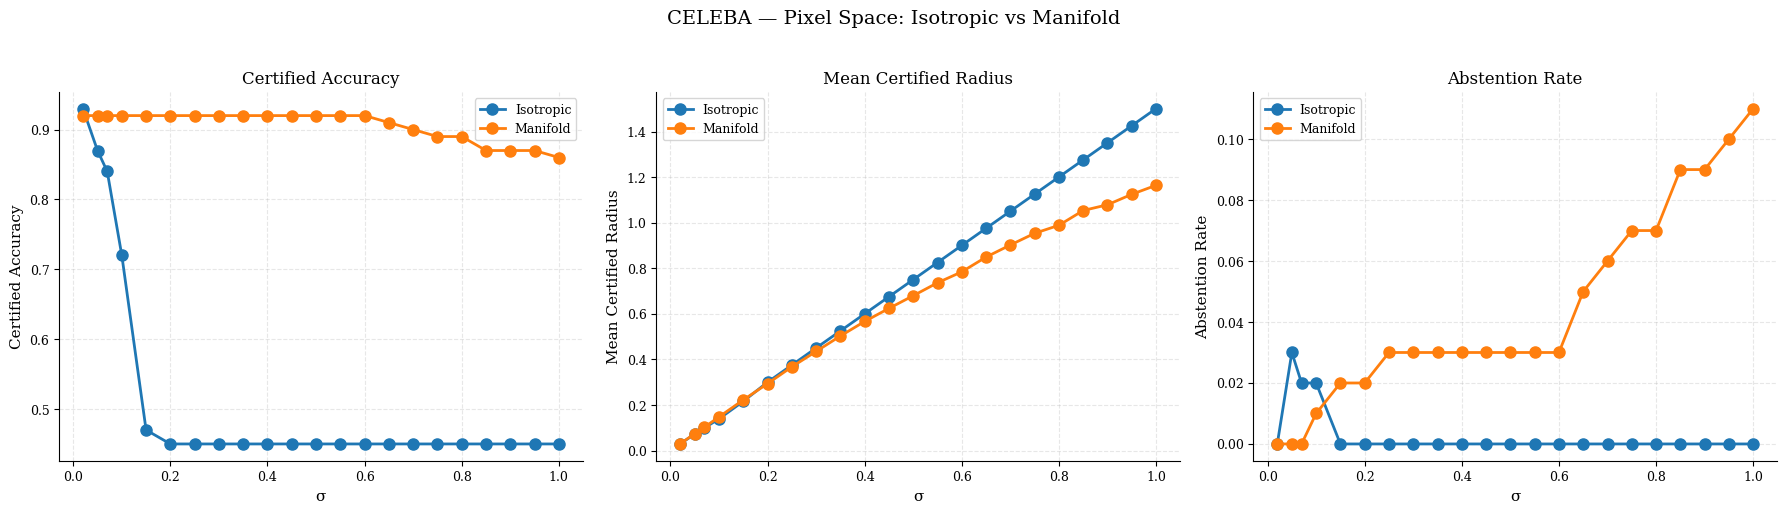

In [5]:
if rows:
    df = pd.DataFrame(rows)
    pixel = df[df['space'] == 'Pixel'].copy()
    
    if len(pixel) > 0:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        for ax, metric, title in zip(axes,
            ['certified_acc', 'mean_radius', 'abstain_rate'],
            ['Certified Accuracy', 'Mean Certified Radius', 'Abstention Rate']):
            for sm in ['Isotropic', 'Manifold']:
                sub = pixel[pixel['smoothing'] == sm].sort_values('sigma')
                if len(sub) > 0:
                    ax.plot(sub['sigma'], sub[metric], 'o-', label=sm, linewidth=2, markersize=8)
            ax.set_xlabel('σ'); ax.set_ylabel(title); ax.set_title(title)
            ax.legend(); ax.grid(True, alpha=0.3)
        plt.suptitle(f'{DATASET.upper()} — Pixel Space: Isotropic vs Manifold', fontsize=14, y=1.02)
        plt.tight_layout(); plt.show()
    else:
        print("No pixel-space results found.")

---
## 3. Isotropic vs Manifold — Latent Space

In [6]:
if rows:
    df = pd.DataFrame(rows)
    latent = df[df['space'] == 'Latent'].copy()
    
    if len(latent) > 0:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        for ax, metric, title in zip(axes,
            ['certified_acc', 'mean_radius', 'abstain_rate'],
            ['Certified Accuracy', 'Mean Certified Radius', 'Abstention Rate']):
            for sm in ['Isotropic', 'Manifold']:
                sub = latent[latent['smoothing'] == sm].sort_values('sigma')
                if len(sub) > 0:
                    ax.plot(sub['sigma'], sub[metric], 'o-', label=sm, linewidth=2, markersize=8)
            ax.set_xlabel('σ'); ax.set_ylabel(title); ax.set_title(title)
            ax.legend(); ax.grid(True, alpha=0.3)
        plt.suptitle(f'{DATASET.upper()} — Latent Space: Isotropic vs Manifold', fontsize=14, y=1.02)
        plt.tight_layout(); plt.show()
    else:
        print("No latent-space results found.")

No latent-space results found.


---
## 4. Pixel vs Latent — All 4 Methods Compared

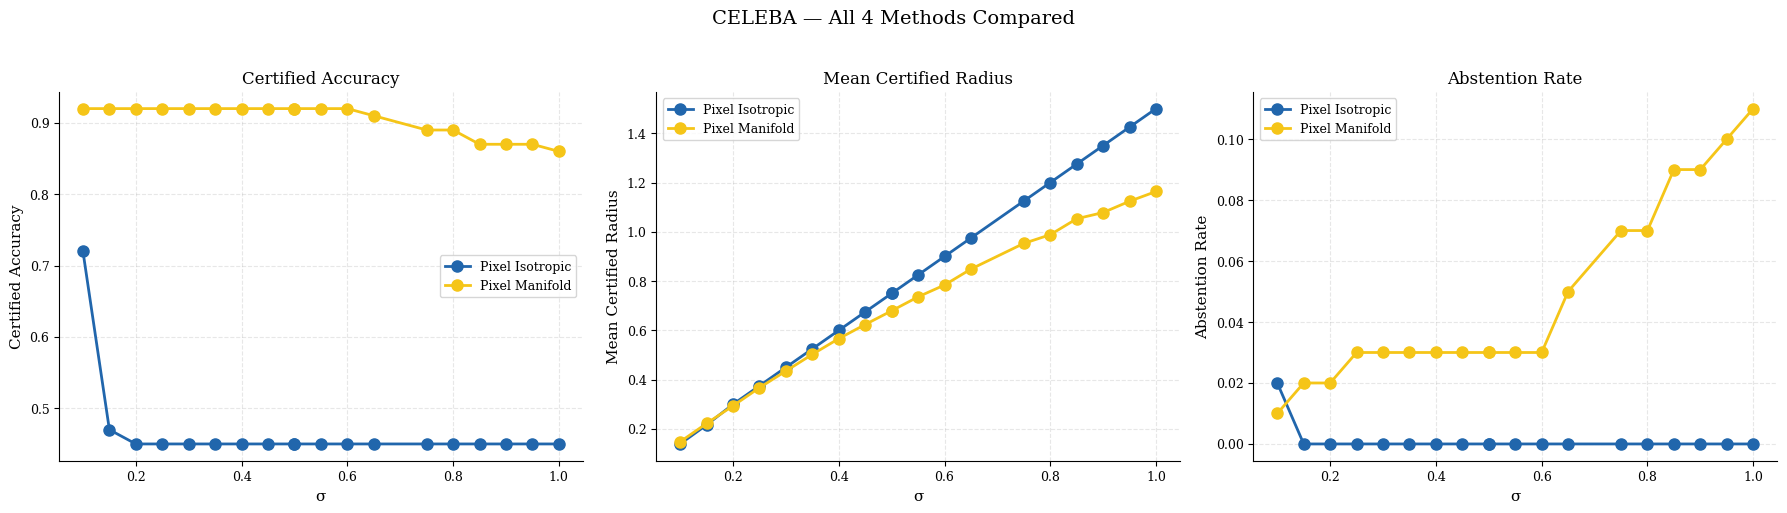

In [5]:
if rows:
    df = pd.DataFrame(rows)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = {
    'Pixel Isotropic':  '#2166ac',   # deep blue   (was orange #d95f02)
    'Pixel Manifold':   '#f5c518',   # yellow/gold (was blue #2166ac)
    'Latent Isotropic': '#aec7e8',   # light blue  (was purple #7b3294)
    'Latent Manifold':  '#74c476',   # green       (was green #008837)
}
    
    for ax, metric, title in zip(axes,
        ['certified_acc', 'mean_radius', 'abstain_rate'],
        ['Certified Accuracy', 'Mean Certified Radius', 'Abstention Rate']):
        for mode_name in colors:
            sub = df[df['mode'] == mode_name].sort_values('sigma')
            if len(sub) > 0:
                ax.plot(sub['sigma'], sub[metric], 'o-', label=mode_name,
                        color=colors[mode_name], linewidth=2, markersize=8)
        ax.set_xlabel('σ'); ax.set_ylabel(title); ax.set_title(title)
        ax.legend(); ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'{DATASET.upper()} — All 4 Methods Compared', fontsize=14, y=1.02)
    plt.tight_layout(); plt.show()

---
## 5. Per-Class (Smile / No-Smile) Comparison

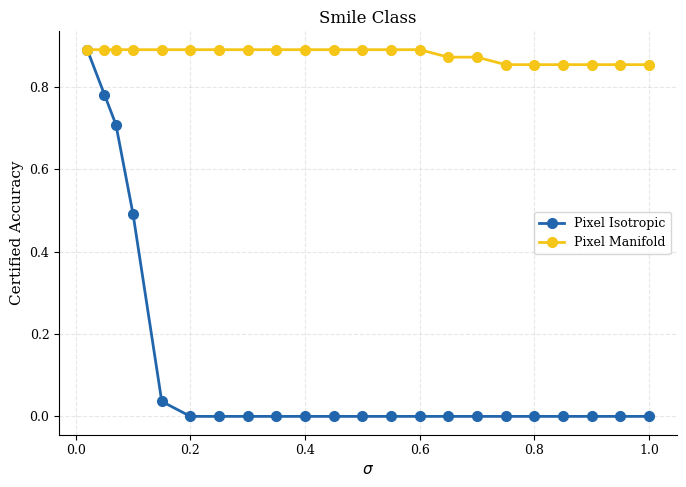

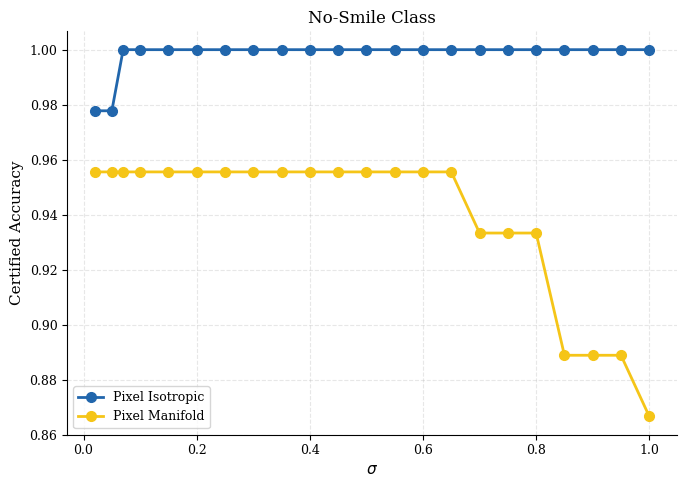

In [7]:
if rows:
    df = pd.DataFrame(rows)

    colors = {
        'Pixel Isotropic':  '#2166ac',
        'Pixel Manifold':   '#f5c518',
        'Latent Isotropic': '#aec7e8',
        'Latent Manifold':  '#74c476',
    }

    plots = [
        ('smile_acc', 'Smile'),
        ('no_smile_acc', 'No-Smile'),
    ]

    for metric, cls_name in plots:
        fig, ax = plt.subplots(figsize=(7,5))

        for mode_name in colors:
            sub = df[df['mode'] == mode_name].sort_values('sigma')
            if len(sub):
                ax.plot(
                    sub['sigma'],
                    sub[metric],
                    'o-',
                    label=mode_name,
                    color=colors[mode_name],
                    linewidth=2,
                    markersize=7,
                )

        ax.set_xlabel(r'$\sigma$')
        ax.set_ylabel('Certified Accuracy')
        ax.set_title(f'{cls_name} Class')
        ax.grid(True, alpha=0.3)
        ax.legend()

        plt.tight_layout()

        plt.savefig(
            f'celeba_perclass_{cls_name.lower().replace("-", "").replace(" ", "")}.png',
            dpi=300,
            bbox_inches='tight'
        )

        plt.show()

---
## 6. Certification Radius Distribution (Per-Sample)

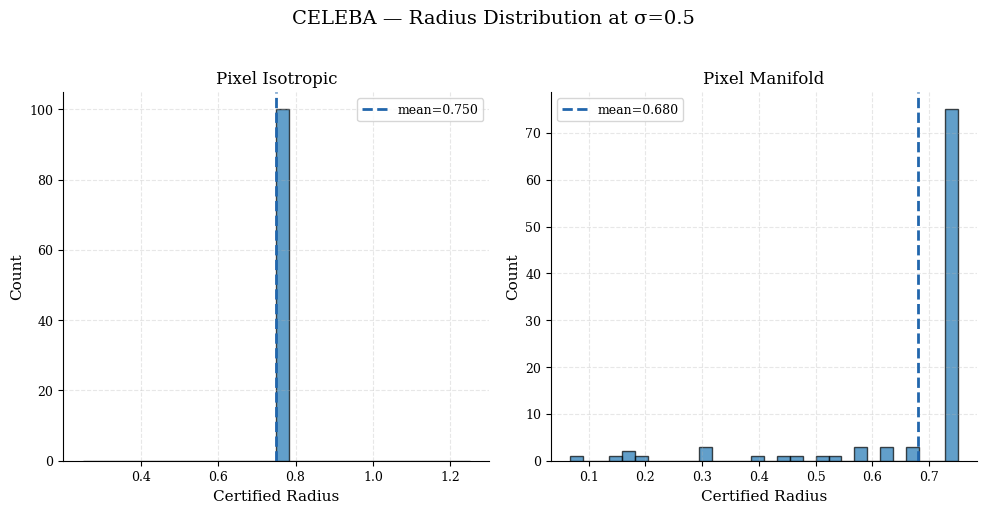

In [7]:
# Load per-sample results for radius histograms at a chosen sigma
TARGET_SIGMA = "sigma_0_50"

csv_data = {}
for mode in MODES:
    df_csv = load_results_csv(certify_dir / mode / TARGET_SIGMA)
    if df_csv is not None:
        csv_data[mode_label(mode)] = df_csv

if csv_data:
    fig, axes = plt.subplots(1, len(csv_data), figsize=(5 * len(csv_data), 5), squeeze=False)
    axes = axes.flat
    
    for ax, (name, df_csv) in zip(axes, csv_data.items()):
        non_abstain = df_csv[df_csv['abstained'] == False]
        radii = non_abstain['radius'].values
        ax.hist(radii, bins=30, alpha=0.7, edgecolor='k')
        ax.axvline(radii.mean(), color='#2166ac', linestyle='--', label=f'mean={radii.mean():.3f}')
        ax.set_xlabel('Certified Radius'); ax.set_ylabel('Count')
        ax.set_title(name); ax.legend(); ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'{DATASET.upper()} — Radius Distribution at σ={sigma_val(TARGET_SIGMA)}',
                 fontsize=14, y=1.02)
    plt.tight_layout(); plt.show()
else:
    print(f"No per-sample results.csv found at σ={sigma_val(TARGET_SIGMA)}")

---
## 7. Certified Accuracy vs Radius Trade-off

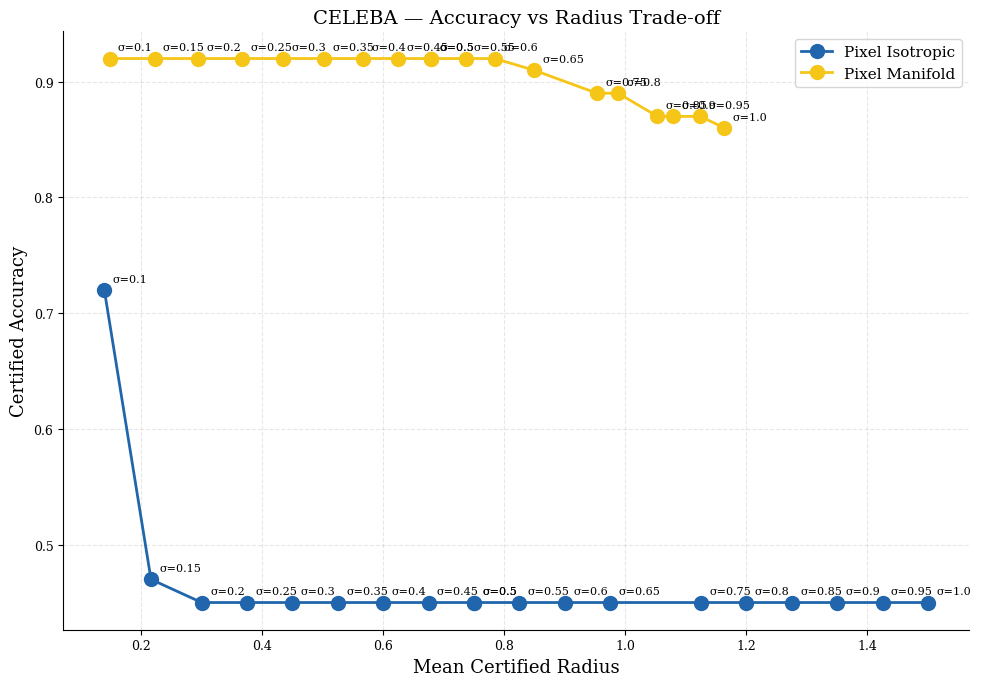

In [8]:
if rows:
    df = pd.DataFrame(rows)
    colors = {
    'Pixel Isotropic':  '#2166ac',   # deep blue   (was orange #d95f02)
    'Pixel Manifold':   '#f5c518',   # yellow/gold (was blue #2166ac)
    'Latent Isotropic': '#aec7e8',   # light blue  (was purple #7b3294)
    'Latent Manifold':  '#74c476',   # green       (was green #008837)
}
    
    fig, ax = plt.subplots(figsize=(10, 7))
    for mode_name in colors:
        sub = df[df['mode'] == mode_name].sort_values('sigma')
        if len(sub) > 0:
            ax.plot(sub['mean_radius'], sub['certified_acc'], 'o-', label=mode_name,
                    color=colors[mode_name], linewidth=2, markersize=10)
            # Annotate with sigma values
            for _, r in sub.iterrows():
                ax.annotate(f'σ={r["sigma"]}', (r['mean_radius'], r['certified_acc']),
                            textcoords='offset points', xytext=(6, 6), fontsize=8)
    
    ax.set_xlabel('Mean Certified Radius', fontsize=13)
    ax.set_ylabel('Certified Accuracy', fontsize=13)
    ax.set_title(f'{DATASET.upper()} — Accuracy vs Radius Trade-off', fontsize=14)
    ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

---
## 8. Heatmap — Certified Accuracy by Mode & σ

In [9]:
if rows:
    df = pd.DataFrame(rows)
    pivot = df.pivot_table(index='mode', columns='sigma', values='certified_acc', aggfunc='first')
    
    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'σ={s}' for s in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.1%}', ha='center', va='center', fontsize=11,
                        fontweight='bold')
    
    plt.colorbar(im, label='Certified Accuracy')
    ax.set_title(f'{DATASET.upper()} — Certified Accuracy Heatmap', fontsize=14)
    plt.tight_layout(); plt.show()

KeyboardInterrupt: 

---
## 9. Per-Sample Correct/Incorrect Breakdown

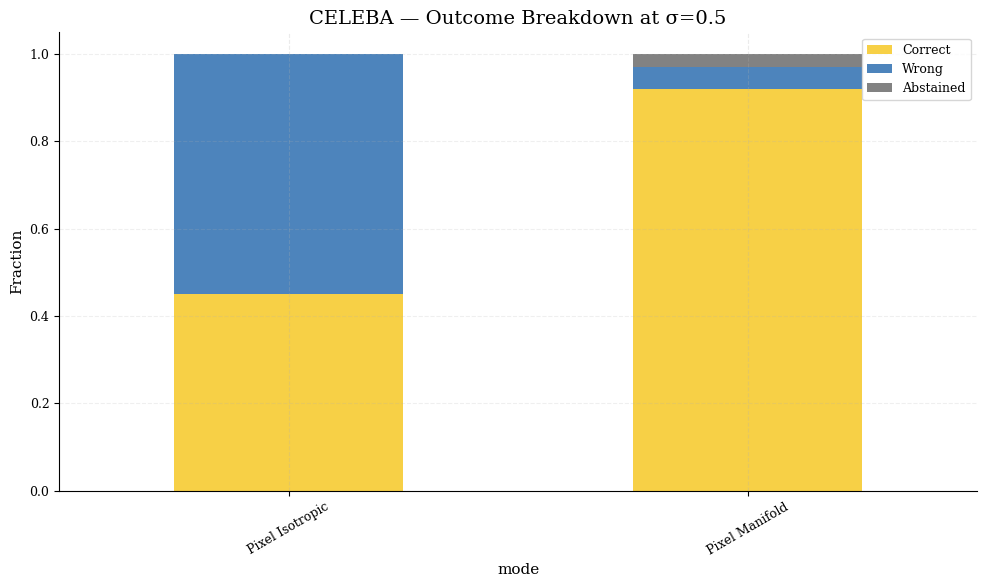

In [10]:
# Stacked bar: correct / incorrect / abstained per mode at a chosen sigma
TARGET_SIGMA = "sigma_0_50"

bar_rows = []
for mode in MODES:
    m = load_metrics(certify_dir / mode / TARGET_SIGMA)
    if m:
        total = m['total_test_samples']
        correct = m['certified_correct']
        abstained = m['abstained_samples']
        wrong = total - correct - abstained
        bar_rows.append({
            'mode': mode_label(mode),
            'Correct': correct / total,
            'Wrong': wrong / total,
            'Abstained': abstained / total,
        })

if bar_rows:
    df_bar = pd.DataFrame(bar_rows).set_index('mode')
    
    fig, ax = plt.subplots(figsize=(10, 6))
    df_bar.plot(kind='bar', stacked=True, ax=ax,
                color=['#f5c518', '#2166ac', '#636363'], alpha=0.8)
    ax.set_ylabel('Fraction'); ax.set_ylim(0, 1.05)
    ax.set_title(f'{DATASET.upper()} — Outcome Breakdown at σ={sigma_val(TARGET_SIGMA)}', fontsize=14)
    ax.legend(loc='upper right'); ax.grid(True, alpha=0.2, axis='y')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout(); plt.show()
else:
    print(f"No results at σ={sigma_val(TARGET_SIGMA)}")

---
## 10. Per-Class Radius Comparison

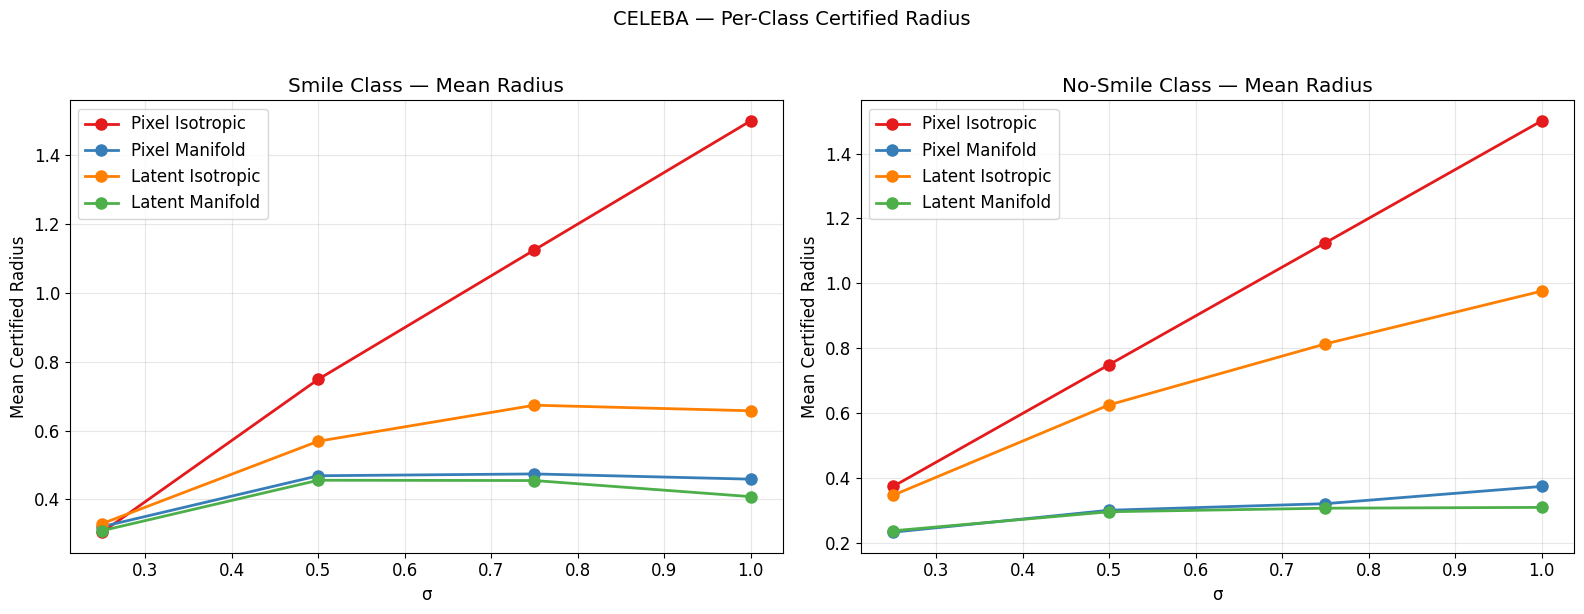

In [29]:
if rows:
    df = pd.DataFrame(rows)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    colors = {
    'Pixel Isotropic':  '#2166ac',   # deep blue   (was orange #d95f02)
    'Pixel Manifold':   '#f5c518',   # yellow/gold (was blue #2166ac)
    'Latent Isotropic': '#aec7e8',   # light blue  (was purple #7b3294)
    'Latent Manifold':  '#74c476',   # green       (was green #008837)
}
    
    for ax, cls_metric, cls_name in zip(axes,
        ['smile_radius', 'no_smile_radius'], ['Smile', 'No-Smile']):
        for mode_name in colors:
            sub = df[df['mode'] == mode_name].sort_values('sigma')
            if len(sub) > 0:
                ax.plot(sub['sigma'], sub[cls_metric], 'o-', label=mode_name,
                        color=colors[mode_name], linewidth=2, markersize=8)
        ax.set_xlabel('σ'); ax.set_ylabel('Mean Certified Radius')
        ax.set_title(f'{cls_name} Class — Mean Radius')
        ax.legend(); ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'{DATASET.upper()} — Per-Class Certified Radius', fontsize=14, y=1.02)
    plt.tight_layout(); plt.show()

---
## 11. Per-Mode Per-σ Detail Table

Columns report certification outcomes plus three different volume quantities:

- **log V_iso,cert,D** = log(C_D r_iso^D), the classical isotropic certified volume in ambient pixel dimension.
- **log V_mani,actual** = log(C_k r_mani^k sqrt(det(Λ))), the actual unscaled manifold certified volume using raw eigenvalues.
- **log V_iso,geo** = log(C_k σ^k), Jonas's k-dimensional isotropic geometry baseline.
- **log V_mani,geo,unscaled** = log(C_k σ^k sqrt(det(Λ))), the unscaled sigma-based manifold geometry volume Jonas asked for.
- **log V_mani,geo,scaled** = log(C_k σ^k sqrt(det(Λ̃))), where Λ̃ = Λ / λ_max; this is a shape-only normalized diagnostic.


In [8]:
if rows:
    df = pd.DataFrame(rows)

    def fmt(v, fmt_str='{:.3f}'):
        return fmt_str.format(v) if v is not None and not (isinstance(v, float) and np.isnan(v)) else '–'

    for mode_name in ['Pixel Isotropic', 'Pixel Manifold', 'Latent Isotropic', 'Latent Manifold']:
        sub = df[df['mode'] == mode_name].sort_values('sigma')
        if sub.empty: continue

        is_mani = 'Manifold' in mode_name
        print(f'\n{"═"*110}')
        print(f'  {mode_name}   |   {int(sub["total"].iloc[0])} test samples')
        print(f'{"═"*110}')

        table_rows = []
        for _, r in sub.iterrows():
            table_rows.append({
                'σ':              f"{r['sigma']:.2f}",
                'CertAcc':        f"{r['certified_acc']*100:.1f}%",
                'Abstain':        f"{r['abstain_rate']*100:.1f}%",
                'SmileAcc':       f"{r['smile_acc']*100:.1f}%",
                'NoSmileAcc':     f"{r['no_smile_acc']*100:.1f}%",
                'log V_iso,cert,D': fmt(r['logV_iso_cert_D'], '{:.2f}'),
                'log V_mani,actual': fmt(r['logV_mani_actual'], '{:.2f}') if is_mani else '–',
                'log V_iso,geo':  fmt(r['logV_iso_geo'],  '{:.2f}'),
                'log V_mani,geo,unscaled': fmt(r['logV_mani_unscaled_geo'], '{:.2f}') if is_mani else '–',
                'log V_mani,geo,scaled': fmt(r['logV_mani_geo_scaled'], '{:.2f}') if is_mani else '–',
            })

        tbl = pd.DataFrame(table_rows)
        bg = '#64625d' if is_mani else '#8b93a8'
        display(tbl.style
                .set_properties(**{'background-color': bg})
                .set_caption(mode_name))
else:
    print('No results — load data first.')



═══════════════════════════════════════════════════════════════════════════════════════════════
  Pixel Isotropic   |   100 test samples
═══════════════════════════════════════════════════════════════════════════════════════════════


,σ,CertAcc,Abstain,SmileAcc,NoSmileAcc,"log V_iso,geo","log V_mani,geo"
0,0.02,93.0%,0.0%,89.1%,97.8%,–,–
1,0.05,87.0%,3.0%,78.2%,97.8%,–,–
2,0.07,84.0%,2.0%,70.9%,100.0%,–,–
3,0.10,72.0%,2.0%,49.1%,100.0%,–,–
4,0.15,47.0%,0.0%,3.6%,100.0%,–,–
5,0.20,45.0%,0.0%,0.0%,100.0%,–,–
6,0.25,45.0%,0.0%,0.0%,100.0%,–,–
7,0.30,45.0%,0.0%,0.0%,100.0%,–,–
8,0.35,45.0%,0.0%,0.0%,100.0%,–,–
9,0.40,45.0%,0.0%,0.0%,100.0%,–,–



═══════════════════════════════════════════════════════════════════════════════════════════════
  Pixel Manifold   |   100 test samples
═══════════════════════════════════════════════════════════════════════════════════════════════


,σ,CertAcc,Abstain,SmileAcc,NoSmileAcc,"log V_iso,geo","log V_mani,geo"
0,0.02,92.0%,0.0%,89.1%,95.6%,-2803.87,-4107.49
1,0.05,92.0%,0.0%,89.1%,95.6%,-2345.73,-3649.34
2,0.07,92.0%,0.0%,89.1%,95.6%,-2177.49,-3481.11
3,0.10,92.0%,1.0%,89.1%,95.6%,-1999.16,-3302.22
4,0.15,92.0%,2.0%,89.1%,95.6%,-1796.42,-3100.12
5,0.20,92.0%,2.0%,89.1%,95.6%,-1652.58,-2956.28
6,0.25,92.0%,3.0%,89.1%,95.6%,-1541.01,-2844.01
7,0.30,92.0%,3.0%,89.1%,95.6%,-1449.85,-2752.85
8,0.35,92.0%,3.0%,89.1%,95.6%,-1372.77,-2675.77
9,0.40,92.0%,3.0%,89.1%,95.6%,-1306.01,-2609.01


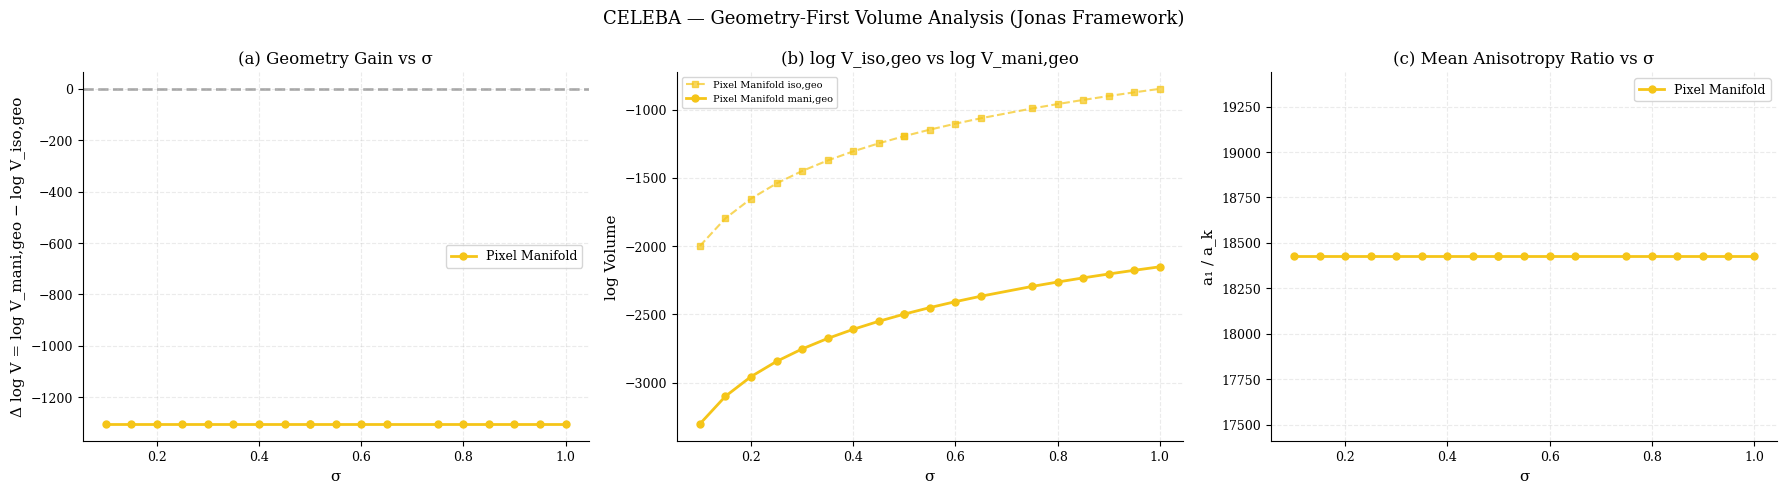

,mode,sigma,k_pca,ambient_D,logV_iso_geo,logV_mani_geo,log_geo_ratio,mean_anisotropy,mean_eff_rank
19,Pixel Manifold,0.100000,500.000000,150528,-1999.155000,-3302.771000,-1303.615000,18425.984000,94.074000
20,Pixel Manifold,0.150000,500.000000,150528,-1796.423000,-3100.038000,-1303.615000,18425.984000,94.074000
21,Pixel Manifold,0.200000,500.000000,150528,-1652.582000,-2956.197000,-1303.615000,18425.984000,94.074000
22,Pixel Manifold,0.250000,500.000000,150528,-1541.010000,-2844.625000,-1303.615000,18425.984000,94.074000
23,Pixel Manifold,0.300000,500.000000,150528,-1449.849000,-2753.464000,-1303.615000,18425.984000,94.074000
24,Pixel Manifold,0.350000,500.000000,150528,-1372.774000,-2676.389000,-1303.615000,18425.984000,94.074000
25,Pixel Manifold,0.400000,500.000000,150528,-1306.008000,-2609.623000,-1303.615000,18425.984000,94.074000
26,Pixel Manifold,0.450000,500.000000,150528,-1247.117000,-2550.732000,-1303.615000,18425.984000,94.074000
27,Pixel Manifold,0.500000,500.000000,150528,-1194.436000,-2498.052000,-1303.615000,18425.984000,94.074000
28,Pixel Manifold,0.550000,500.000000,150528,-1146.781000,-2450.397000,-1303.615000,18425.984000,94.074000


In [10]:
if rows:
    df = pd.DataFrame(rows)
    mani = df[df['smoothing']=='Manifold'].copy()
    if mani.empty:
        print('No manifold results found.')
    else:
        colors_mode = {'Pixel Manifold': '#f5c518', 'Latent Manifold': '#74c476'}

        fig, axes = plt.subplots(1, 3, figsize=(19, 5))

        # (a) Raw/unscaled geometry factor vs sigma.
        for mode_name, c in colors_mode.items():
            sub = mani[mani['mode']==mode_name].sort_values('sigma')
            if sub.empty or sub['log_geo_ratio_unscaled'].isna().all(): continue
            axes[0].plot(sub['sigma'], sub['log_geo_ratio_unscaled'], 'o-',
                         color=c, lw=2, label=f'{mode_name} unscaled')
        axes[0].axhline(0, color='#636363', ls='--', alpha=0.5)
        axes[0].set_xlabel('σ')
        axes[0].set_ylabel('0.5 Σ log λ_j')
        axes[0].set_title('(a) Raw Geometry Factor')
        axes[0].legend()

        # (b) Jonas sigma-based volumes: iso baseline, unscaled mani, scaled diagnostic.
        for mode_name, c in colors_mode.items():
            sub = mani[mani['mode']==mode_name].sort_values('sigma')
            if sub.empty: continue
            axes[1].plot(sub['sigma'], sub['logV_iso_geo'], 's--', color='#2166ac', lw=1.5,
                         alpha=0.65, label='iso geo baseline' if mode_name == list(colors_mode)[0] else None)
            axes[1].plot(sub['sigma'], sub['logV_mani_unscaled_geo'], 'o-', color=c, lw=2,
                         label=f'{mode_name} mani geo unscaled')
            if sub['logV_mani_geo_scaled'].notna().any():
                axes[1].plot(sub['sigma'], sub['logV_mani_geo_scaled'], '^:', color=c, lw=1.8,
                             label=f'{mode_name} mani geo scaled')
        axes[1].set_xlabel('σ')
        axes[1].set_ylabel('log Volume')
        axes[1].set_title('(b) Sigma-Based Geometry Volumes')
        axes[1].legend(fontsize=7)

        # (c) Actual certified manifold volume, when present.
        for mode_name, c in colors_mode.items():
            sub = mani[mani['mode']==mode_name].sort_values('sigma')
            if sub.empty or sub['logV_mani_actual'].isna().all(): continue
            axes[2].plot(sub['sigma'], sub['logV_mani_actual'], 'o-',
                         color=c, lw=2, label=f'{mode_name} actual cert')
        axes[2].set_xlabel('σ')
        axes[2].set_ylabel('log Volume')
        axes[2].set_title('(c) Actual Certified Mani Volume')
        axes[2].legend()

        fig.suptitle(f'{DATASET.upper()} — Unscaled and Scaled Geometry Volume Analysis', fontsize=13)
        plt.tight_layout()
        plt.savefig('fig_geometry_volume_unscaled.pdf', bbox_inches='tight')
        plt.show()

        cols = ['mode','sigma','k_pca','ambient_D',
                'logV_iso_geo','logV_mani_unscaled_geo','logV_mani_geo_scaled',
                'geometry_factor_raw','logV_mani_actual','mean_anisotropy','mean_eff_rank']
        avail = [c for c in cols if c in mani.columns]
        display(mani[avail].round(3).style
                .background_gradient(subset=['geometry_factor_raw'], cmap='RdYlGn')
                .set_caption('Geometry Volume Summary: unscaled actual experiment plus scaled diagnostic'))
